In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv('/content/house_data (1).csv')

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.shape

(1460, 81)

In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
Id,0.000000
MSSubClass,0.000000
MSZoning,0.000000
LotFrontage,17.739726
LotArea,0.000000
...,...
MoSold,0.000000
YrSold,0.000000
SaleType,0.000000
SaleCondition,0.000000


In [ ]:
df.isnull().sum().sum()

np.int64(7829)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['LotFrontage'].mean()

np.float64(70.04995836802665)

In [ ]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df = df.drop('Alley' , axis = 1)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [ ]:
# ye hum ko missing value bty ga knsy column mai kitni missing value h or us colum ka naam print hojay ga
for i in df.columns:
 if(df[i].dtype == 'object' and df[i].isna().sum()!=0):
   print(i , df[i].dtype , df[i].isna().sum())

MasVnrType object 872
BsmtQual object 37
BsmtCond object 37
BsmtExposure object 38
BsmtFinType1 object 37
BsmtFinType2 object 38
Electrical object 1
FireplaceQu object 690
GarageType object 81
GarageFinish object 81
GarageQual object 81
GarageCond object 81
PoolQC object 1453
Fence object 1179
MiscFeature object 1406


In [ ]:
df=df.drop(['MasVnrType','FireplaceQu','PoolQC','Fence','MiscFeature'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [ ]:
df.shape

(1460, 75)

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'object' and df[i].isna().sum()!=0):
  print(i , df[i].dtype , df[i].isna().sum())

BsmtQual object 37
BsmtCond object 37
BsmtExposure object 38
BsmtFinType1 object 37
BsmtFinType2 object 38
Electrical object 1
GarageType object 81
GarageFinish object 81
GarageQual object 81
GarageCond object 81


In [ ]:
# row drop
df.dropna(subset = 'BsmtQual' , axis = 0 , inplace = True)
df.dropna(subset = 'BsmtCond' , axis = 0 , inplace = True)
df.dropna(subset = 'BsmtExposure' , axis = 0 , inplace = True)
df.dropna(subset = 'BsmtFinType1' , axis = 0 , inplace = True)
df.dropna(subset = 'BsmtFinType2' , axis = 0 , inplace = True)
df.dropna(subset = 'Electrical' , axis = 0 , inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1420 non-null   int64  
 1   MSSubClass     1420 non-null   int64  
 2   MSZoning       1420 non-null   object 
 3   LotFrontage    1420 non-null   float64
 4   LotArea        1420 non-null   int64  
 5   Street         1420 non-null   object 
 6   LotShape       1420 non-null   object 
 7   LandContour    1420 non-null   object 
 8   Utilities      1420 non-null   object 
 9   LotConfig      1420 non-null   object 
 10  LandSlope      1420 non-null   object 
 11  Neighborhood   1420 non-null   object 
 12  Condition1     1420 non-null   object 
 13  Condition2     1420 non-null   object 
 14  BldgType       1420 non-null   object 
 15  HouseStyle     1420 non-null   object 
 16  OverallQual    1420 non-null   int64  
 17  OverallCond    1420 non-null   int64  
 18  YearBuilt    

In [ ]:
df[['MasVnrArea', 'GarageType', 'GarageYrBlt','GarageFinish','GarageQual','GarageCond']].isna().sum()

,0
MasVnrArea,8
GarageType,74
GarageYrBlt,74
GarageFinish,74
GarageQual,74
GarageCond,74


In [ ]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].mean())

In [ ]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1420 non-null   int64  
 1   MSSubClass     1420 non-null   int64  
 2   MSZoning       1420 non-null   object 
 3   LotFrontage    1420 non-null   float64
 4   LotArea        1420 non-null   int64  
 5   Street         1420 non-null   object 
 6   LotShape       1420 non-null   object 
 7   LandContour    1420 non-null   object 
 8   Utilities      1420 non-null   object 
 9   LotConfig      1420 non-null   object 
 10  LandSlope      1420 non-null   object 
 11  Neighborhood   1420 non-null   object 
 12  Condition1     1420 non-null   object 
 13  Condition2     1420 non-null   object 
 14  BldgType       1420 non-null   object 
 15  HouseStyle     1420 non-null   object 
 16  OverallQual    1420 non-null   int64  
 17  OverallCond    1420 non-null   int64  
 18  YearBuilt    

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'int64' and df[i].isna().sum()!=0):
  print(i , df[i].dtype , df[i].isna().sum())

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'float64' and df[i].isna().sum()!=0):
  print(i , df[i].dtype , df[i].isna().sum())

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'object' and df[i].isna().sum()!=0):
  print(i , df[i].dtype , df[i].isna().sum())

GarageType object 74
GarageFinish object 74
GarageQual object 74
GarageCond object 74


In [ ]:
df.dropna(subset = 'GarageType' , axis = 0 )
df.dropna(subset = 'GarageFinish' , axis = 0 )
df.dropna(subset = 'GarageQual' , axis = 0 )
df.dropna(subset = 'GarageCond' , axis = 0 )

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1420 non-null   int64  
 1   MSSubClass     1420 non-null   int64  
 2   MSZoning       1420 non-null   object 
 3   LotFrontage    1420 non-null   float64
 4   LotArea        1420 non-null   int64  
 5   Street         1420 non-null   object 
 6   LotShape       1420 non-null   object 
 7   LandContour    1420 non-null   object 
 8   Utilities      1420 non-null   object 
 9   LotConfig      1420 non-null   object 
 10  LandSlope      1420 non-null   object 
 11  Neighborhood   1420 non-null   object 
 12  Condition1     1420 non-null   object 
 13  Condition2     1420 non-null   object 
 14  BldgType       1420 non-null   object 
 15  HouseStyle     1420 non-null   object 
 16  OverallQual    1420 non-null   int64  
 17  OverallCond    1420 non-null   int64  
 18  YearBuilt    

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'object' and df[i].isna().sum()!=0):
  print(i , df[i].dtype , df[i].isna().sum())

GarageType object 74
GarageFinish object 74
GarageQual object 74
GarageCond object 74


In [ ]:
for i in df.columns:
 if(df[i].dtype == 'int64' and (df[i]==0).sum()!=0):
  print(i , df[i].dtype , (df[i]==0).sum())

BsmtFinSF1 int64 428
BsmtFinSF2 int64 1254
BsmtUnfSF int64 81
2ndFlrSF int64 801
LowQualFinSF int64 1395
BsmtFullBath int64 817
BsmtHalfBath int64 1338
FullBath int64 9
HalfBath int64 875
BedroomAbvGr int64 6
KitchenAbvGr int64 1
Fireplaces int64 661
GarageCars int64 74
GarageArea int64 74
WoodDeckSF int64 729
OpenPorchSF int64 625
EnclosedPorch int64 1216
3SsnPorch int64 1397
ScreenPorch int64 1304
PoolArea int64 1413
MiscVal int64 1371


In [ ]:
df = df.drop(['MiscVal','PoolArea','ScreenPorch', '3SsnPorch' ,
'EnclosedPorch' , 'HalfBath' ,'BsmtHalfBath','LowQualFinSF','BsmtFinSF2'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 66 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1420 non-null   int64  
 1   MSSubClass     1420 non-null   int64  
 2   MSZoning       1420 non-null   object 
 3   LotFrontage    1420 non-null   float64
 4   LotArea        1420 non-null   int64  
 5   Street         1420 non-null   object 
 6   LotShape       1420 non-null   object 
 7   LandContour    1420 non-null   object 
 8   Utilities      1420 non-null   object 
 9   LotConfig      1420 non-null   object 
 10  LandSlope      1420 non-null   object 
 11  Neighborhood   1420 non-null   object 
 12  Condition1     1420 non-null   object 
 13  Condition2     1420 non-null   object 
 14  BldgType       1420 non-null   object 
 15  HouseStyle     1420 non-null   object 
 16  OverallQual    1420 non-null   int64  
 17  OverallCond    1420 non-null   int64  
 18  YearBuilt    

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'int64' and (df[i]==0).sum()!=0):
  print(i , df[i].dtype , (df[i]==0).sum())

BsmtFinSF1 int64 428
BsmtUnfSF int64 81
2ndFlrSF int64 801
BsmtFullBath int64 817
FullBath int64 9
BedroomAbvGr int64 6
KitchenAbvGr int64 1
Fireplaces int64 661
GarageCars int64 74
GarageArea int64 74
WoodDeckSF int64 729
OpenPorchSF int64 625


In [ ]:
df['BsmtFinSF1'].mean()
df['BsmtFinSF1'] = df['BsmtFinSF1'].replace( 0, df['BsmtFinSF1'].mean())
df['BsmtUnfSF'] = df['BsmtUnfSF'].replace( 0, df['BsmtUnfSF'].mean())
df['2ndFlrSF'] = df['2ndFlrSF'].replace( 0, df['2ndFlrSF'].mean())
df['BsmtFullBath'] = df['BsmtFullBath'].replace( 0,
df['BsmtFullBath'].mean())
df['FullBath'] = df['FullBath'].replace( 0, df['FullBath'].mean())
df['BedroomAbvGr'] = df['BedroomAbvGr'].replace( 0,
df['BedroomAbvGr'].mean())
df['Fireplaces'] = df['Fireplaces'].replace( 0,
df['Fireplaces'].mean())
df['WoodDeckSF'] = df['WoodDeckSF'].replace( 0,
df['WoodDeckSF'].mean())
df['OpenPorchSF'] = df['OpenPorchSF'].replace( 0,
df['OpenPorchSF'].mean())

In [ ]:
df['GarageArea'] = df['GarageArea'].replace( 0, df['GarageArea'].mean())
df['GarageCars'] = df['GarageCars'].replace( 0, df['GarageCars'].mean())

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'int64' and (df[i]==0).sum()!=0):
  print(i , df[i].dtype , (df[i]==0).sum())

KitchenAbvGr int64 1


In [ ]:
df['KitchenAbvGr'] = df['KitchenAbvGr'].replace( 0,
df['KitchenAbvGr'].mean())

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'float64' and (df[i]==0).sum()!=0):
  print(i , df[i].dtype , (df[i]==0).sum())

MasVnrArea float64 828


In [ ]:
df['MasVnrArea'] = df['MasVnrArea'].replace( 0,
df['MasVnrArea'].mean())

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'object'):
  print(i , df[i].dtype)

MSZoning object
Street object
LotShape object
LandContour object
Utilities object
LotConfig object
LandSlope object
Neighborhood object
Condition1 object
Condition2 object
BldgType object
HouseStyle object
RoofStyle object
RoofMatl object
Exterior1st object
Exterior2nd object
ExterQual object
ExterCond object
Foundation object
BsmtQual object
BsmtCond object
BsmtExposure object
BsmtFinType1 object
BsmtFinType2 object
Heating object
HeatingQC object
CentralAir object
Electrical object
KitchenQual object
Functional object
GarageType object
GarageFinish object
GarageQual object
GarageCond object
PavedDrive object
SaleType object
SaleCondition object


In [ ]:
for i in df.columns:
 if(df[i].dtype == 'object'):
  print(i , df[i].value_counts())

MSZoning MSZoning
RL         1116
RM          214
FV           65
RH           15
C (all)      10
Name: count, dtype: int64
Street Street
Pave    1414
Grvl       6
Name: count, dtype: int64
LotShape LotShape
Reg    892
IR1    478
IR2     40
IR3     10
Name: count, dtype: int64
LandContour LandContour
Lvl    1275
Bnk      61
HLS      50
Low      34
Name: count, dtype: int64
Utilities Utilities
AllPub    1419
NoSeWa       1
Name: count, dtype: int64
LotConfig LotConfig
Inside     1021
Corner      257
CulDSac      92
FR2          46
FR3           4
Name: count, dtype: int64
LandSlope LandSlope
Gtl    1343
Mod      64
Sev      13
Name: count, dtype: int64
Neighborhood Neighborhood
NAmes      215
CollgCr    149
OldTown    111
Edwards     89
Somerst     86
Gilbert     78
NridgHt     76
NWAmes      73
Sawyer      72
BrkSide     55
SawyerW     55
Crawfor     51
Mitchel     47
NoRidge     41
Timber      37
IDOTRR      36
ClearCr     27
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for i in df.columns:
 if(df[i].dtype == 'object'):
  df[i] = le.fit_transform(df[i])
  print(i , df[i].value_counts())

MSZoning MSZoning
3    1116
4     214
1      65
2      15
0      10
Name: count, dtype: int64
Street Street
1    1414
0       6
Name: count, dtype: int64
LotShape LotShape
3    892
0    478
1     40
2     10
Name: count, dtype: int64
LandContour LandContour
3    1275
0      61
1      50
2      34
Name: count, dtype: int64
Utilities Utilities
0    1419
1       1
Name: count, dtype: int64
LotConfig LotConfig
4    1021
0     257
1      92
2      46
3       4
Name: count, dtype: int64
LandSlope LandSlope
0    1343
1      64
2      13
Name: count, dtype: int64
Neighborhood Neighborhood
12    215
5     149
17    111
7      89
21     86
8      78
16     76
14     73
19     72
3      55
20     55
6      51
11     47
15     41
23     37
9      36
4      27
18     25
22     25
0      17
10     17
2      16
24     11
13      9
1       2
Name: count, dtype: int64
Condition1 Condition1
2    1228
1      75
0      47
6      26
4      19
5      10
3       8
8       5
7       2
Name: count, dtype: int6

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 66 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1420 non-null   int64  
 1   MSSubClass     1420 non-null   int64  
 2   MSZoning       1420 non-null   int64  
 3   LotFrontage    1420 non-null   float64
 4   LotArea        1420 non-null   int64  
 5   Street         1420 non-null   int64  
 6   LotShape       1420 non-null   int64  
 7   LandContour    1420 non-null   int64  
 8   Utilities      1420 non-null   int64  
 9   LotConfig      1420 non-null   int64  
 10  LandSlope      1420 non-null   int64  
 11  Neighborhood   1420 non-null   int64  
 12  Condition1     1420 non-null   int64  
 13  Condition2     1420 non-null   int64  
 14  BldgType       1420 non-null   int64  
 15  HouseStyle     1420 non-null   int64  
 16  OverallQual    1420 non-null   int64  
 17  OverallCond    1420 non-null   int64  
 18  YearBuilt    

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(1420, 66)

**Correlation**

In [ ]:
cor = df.select_dtypes(include=['number'])
cor.corr()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,1.000000,0.010277,-0.007326,-0.010983,-0.034743,0.009027,0.035620,-0.023172,0.013497,0.059853,...,-0.008150,-0.015087,0.004092,-0.015099,-0.006509,0.028720,-0.006295,0.020467,-0.008041,-0.021178
MSSubClass,0.010277,1.000000,0.034350,-0.361782,-0.140048,-0.025490,0.114236,-0.000815,-0.023120,0.073086,...,0.031262,0.024432,-0.055488,-0.035171,-0.014288,-0.016179,-0.026385,0.016420,-0.023757,-0.083768
MSZoning,-0.007326,0.034350,1.000000,-0.106769,-0.034071,0.087894,0.060810,-0.019162,-0.001143,-0.011924,...,-0.121688,-0.056102,-0.098954,-0.009340,-0.114387,-0.032481,-0.023797,0.098152,0.008832,-0.166223
LotFrontage,-0.010983,-0.361782,-0.106769,1.000000,0.305160,-0.037163,-0.143139,-0.078518,-0.000107,-0.181958,...,0.015207,0.002813,0.087391,0.083113,0.115958,0.006162,0.005542,-0.029847,0.057385,0.335070
LotArea,-0.034743,-0.140048,-0.034071,0.305160,1.000000,-0.197268,-0.164434,-0.152864,0.010061,-0.121855,...,-0.007463,-0.003476,0.012354,0.199949,0.078154,-0.000946,-0.014190,0.012537,0.033131,0.263939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MoSold,0.028720,-0.016179,-0.032481,0.006162,-0.000946,0.003864,-0.035830,-0.014742,-0.052166,0.015582,...,0.005976,-0.002327,0.003748,0.000690,0.066404,1.000000,-0.148804,-0.045039,0.011149,0.043076
YrSold,-0.006295,-0.026385,-0.023797,0.005542,-0.014190,-0.025716,0.033905,0.026041,0.023827,-0.006930,...,0.041135,0.033230,0.007855,0.022002,-0.039125,-0.148804,1.000000,0.001463,0.010943,-0.026196
SaleType,0.020467,0.016420,0.098152,-0.029847,0.012537,0.014327,-0.000039,-0.024842,-0.128270,0.011669,...,-0.018445,-0.002846,-0.033122,0.065799,-0.012093,-0.045039,0.001463,1.000000,0.190122,-0.050862
SaleCondition,-0.008041,-0.023757,0.008832,0.057385,0.033131,0.006280,-0.034973,0.022595,-0.090619,0.057074,...,-0.000610,-0.032089,0.074899,0.046951,0.014815,0.011149,0.010943,0.190122,1.000000,0.214999


**corr ka heatmap**

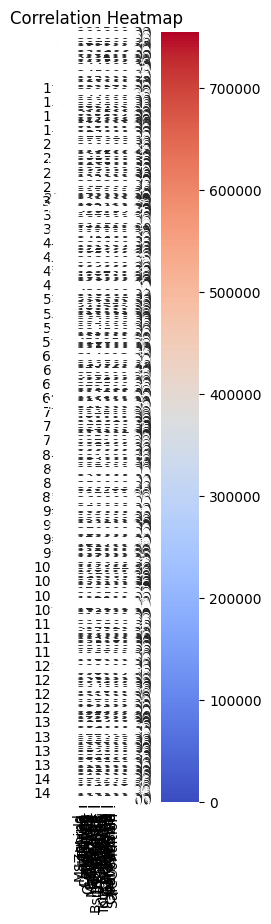

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cor,
    annot=True,      # Values show karega
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # Color theme
    square=True,     # Square boxes
    linewidths=0.5   # Boxes ke darmiyan line
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.shape

(1420, 66)

In [ ]:
G1 = df.iloc[ : , :22]
G1.shape

(1420, 22)

In [ ]:
G2 = df.iloc[:, 22:44]
G2.shape

(1420, 22)

In [ ]:
G3 = df.iloc[:, 44:66]
G3.shape

(1420, 22)

<Axes: >

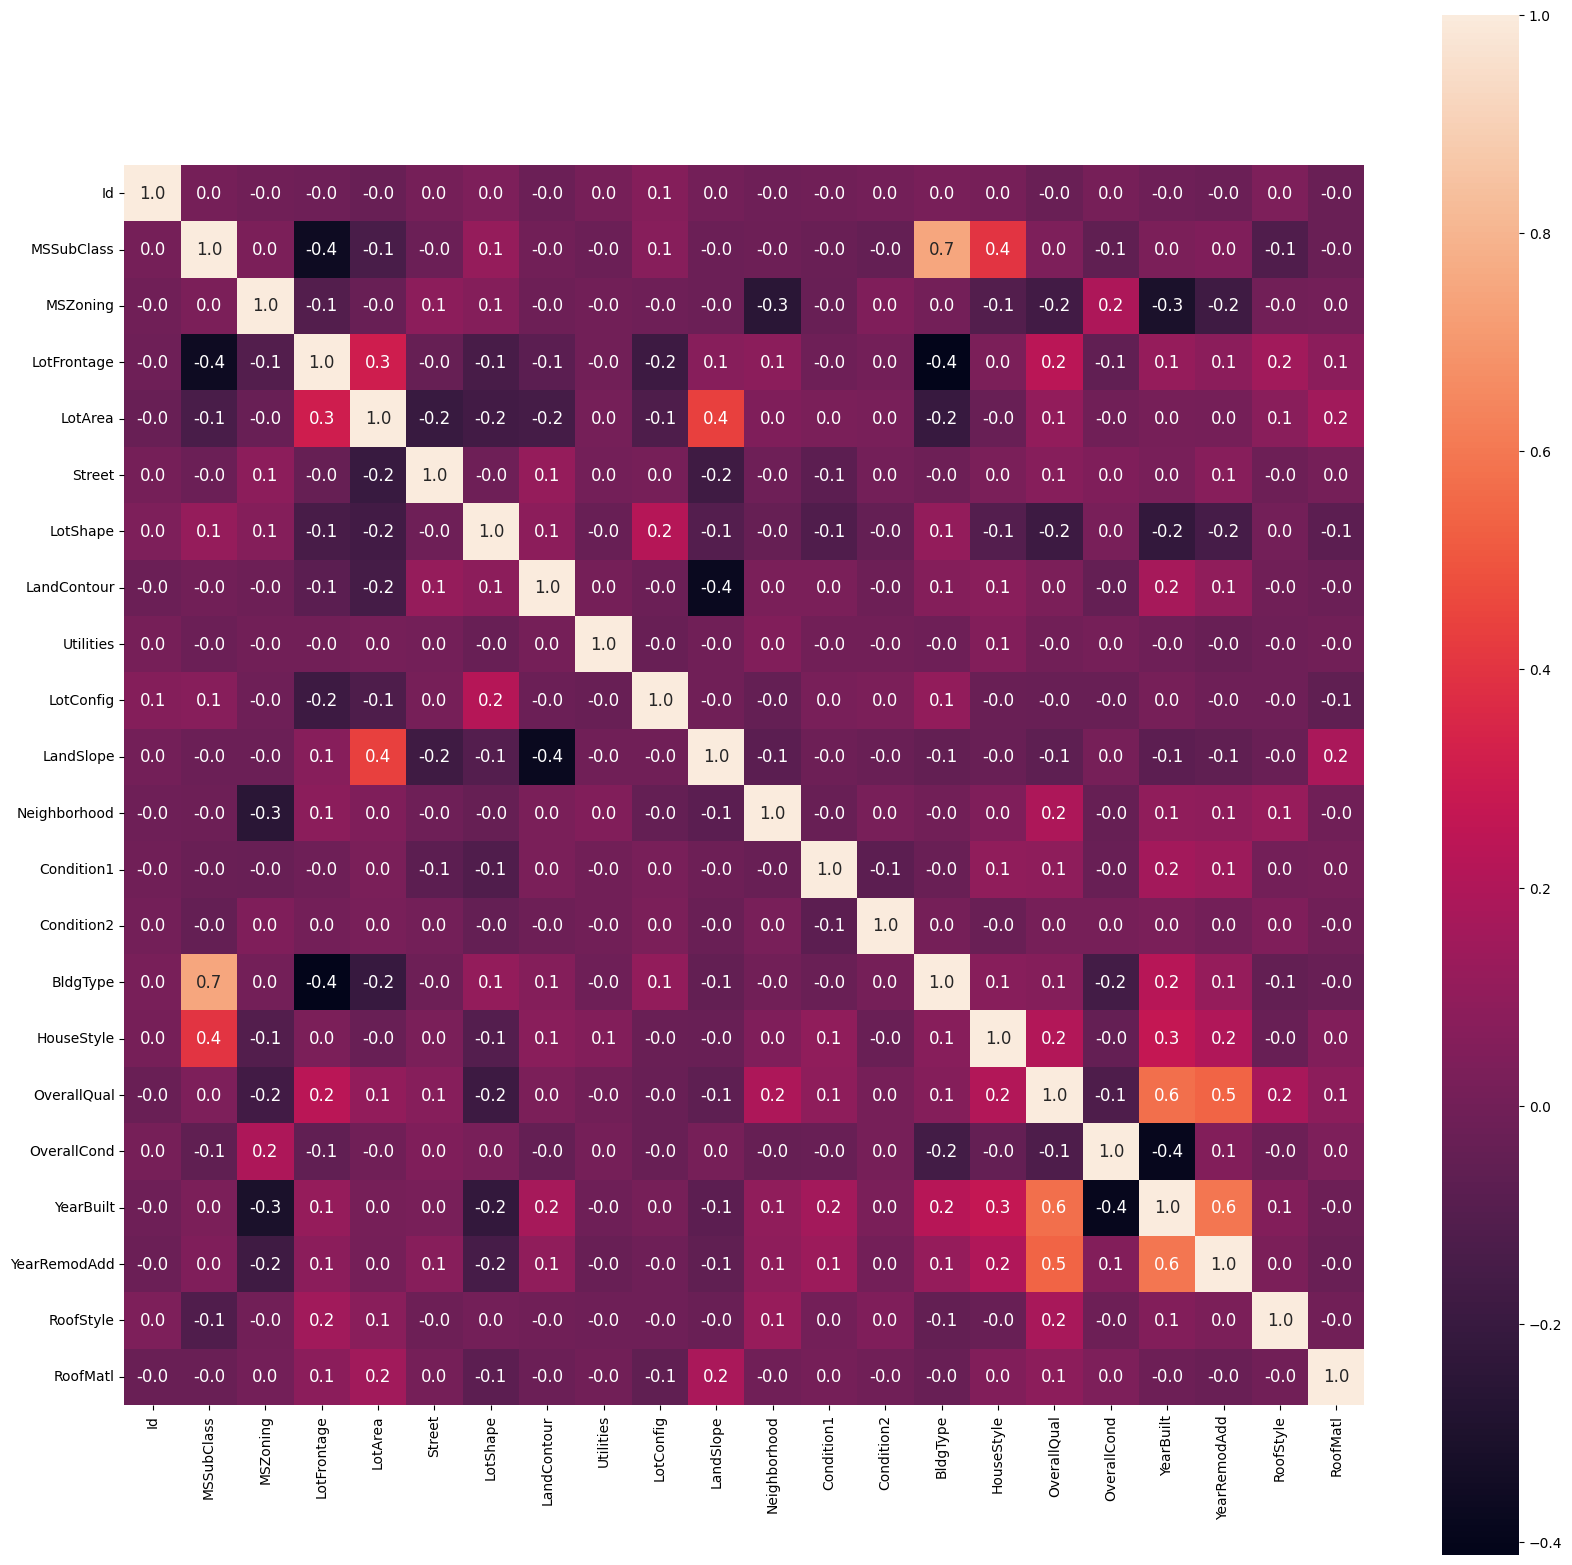

In [ ]:
correlation = G1.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True,
annot_kws={'size':12})

In [ ]:
G1 = G1.drop(['RoofMatl','RoofStyle','OverallCond','Condition2',
'Condition1' ,'Neighborhood' , 'LotConfig' , 'Utilities' , 'LandContour' ,
'Street','MSZoning','Id'] , axis = 1)

In [ ]:
G1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    1420 non-null   int64  
 1   LotFrontage   1420 non-null   float64
 2   LotArea       1420 non-null   int64  
 3   LotShape      1420 non-null   int64  
 4   LandSlope     1420 non-null   int64  
 5   BldgType      1420 non-null   int64  
 6   HouseStyle    1420 non-null   int64  
 7   OverallQual   1420 non-null   int64  
 8   YearBuilt     1420 non-null   int64  
 9   YearRemodAdd  1420 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 122.0 KB


<Axes: >

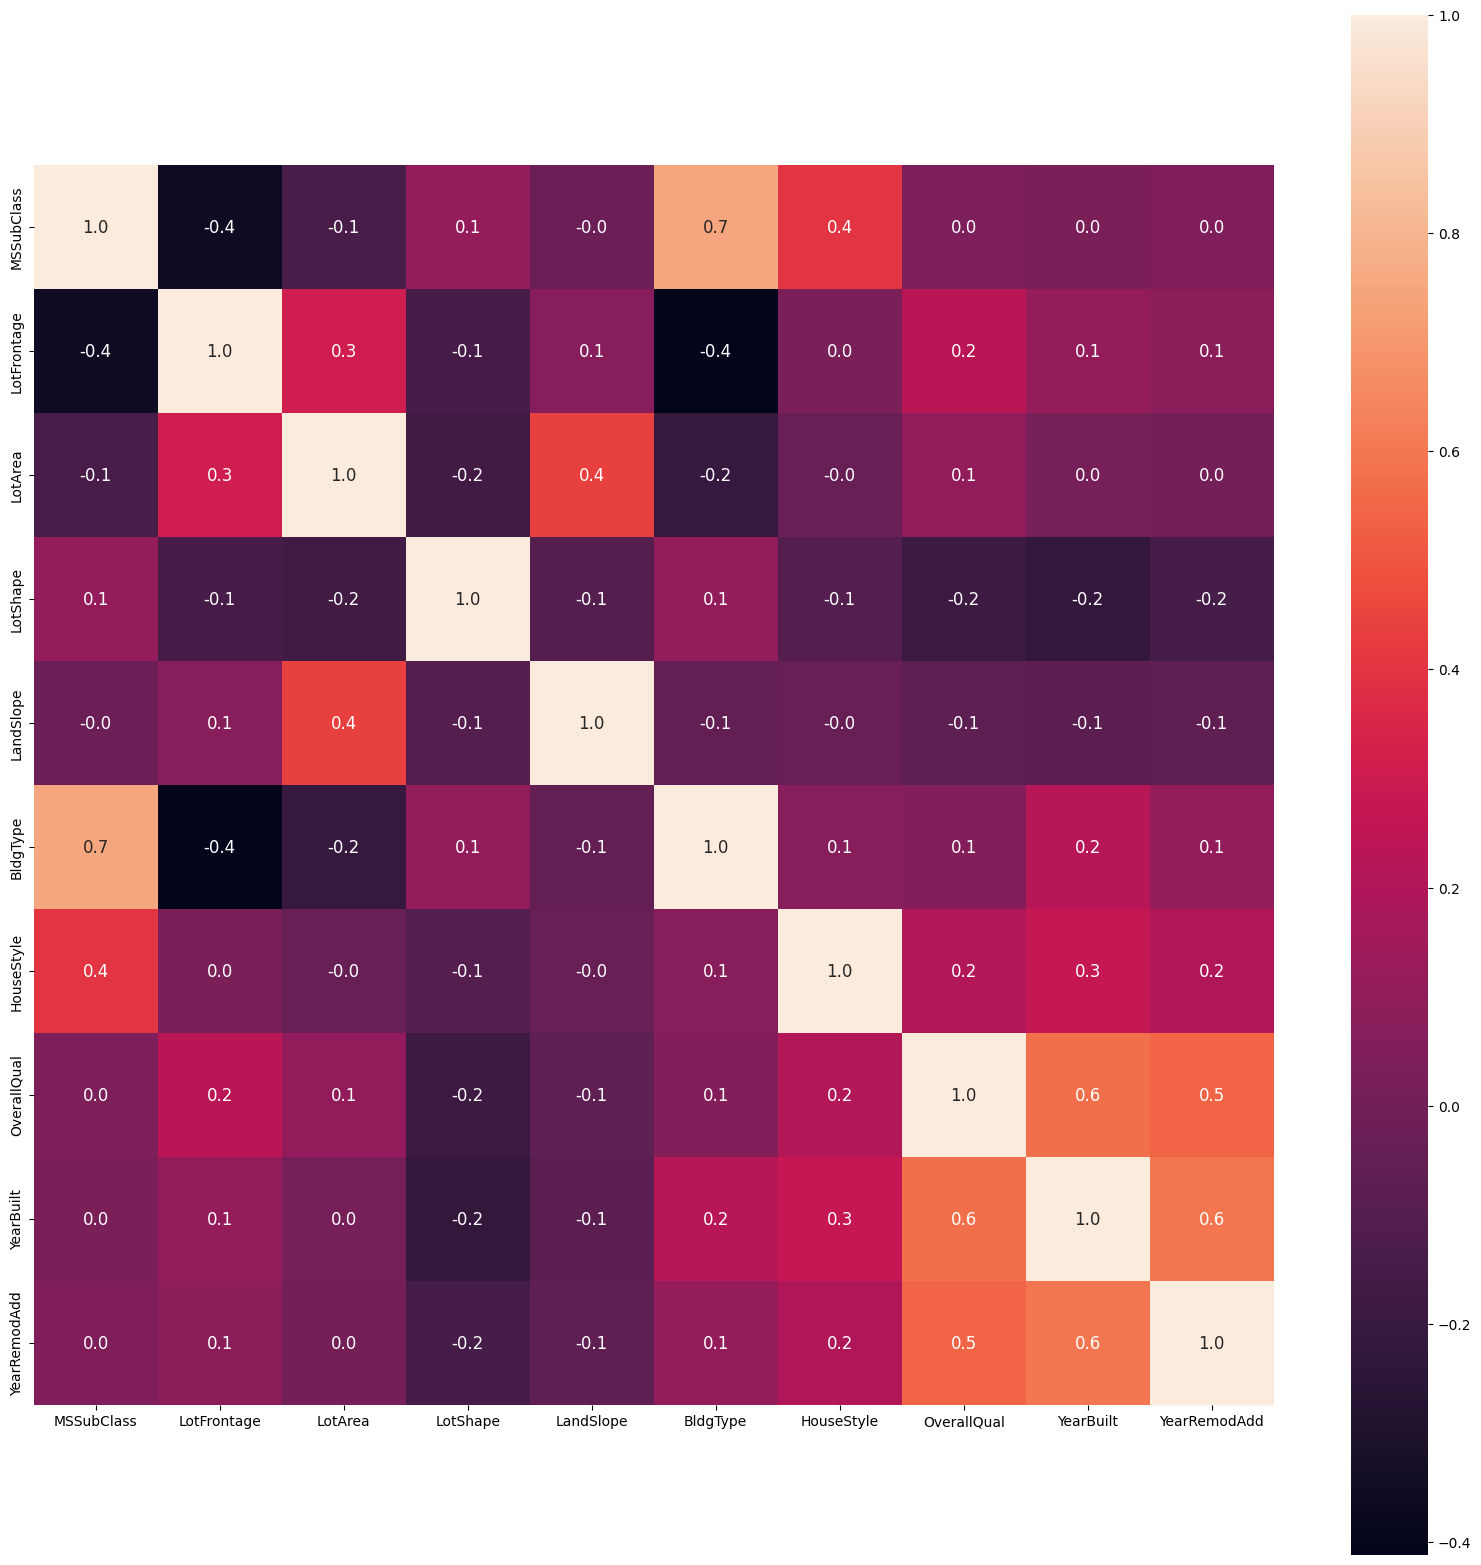

In [ ]:
correlation = G1.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True,
annot_kws={'size':12})

<Axes: >

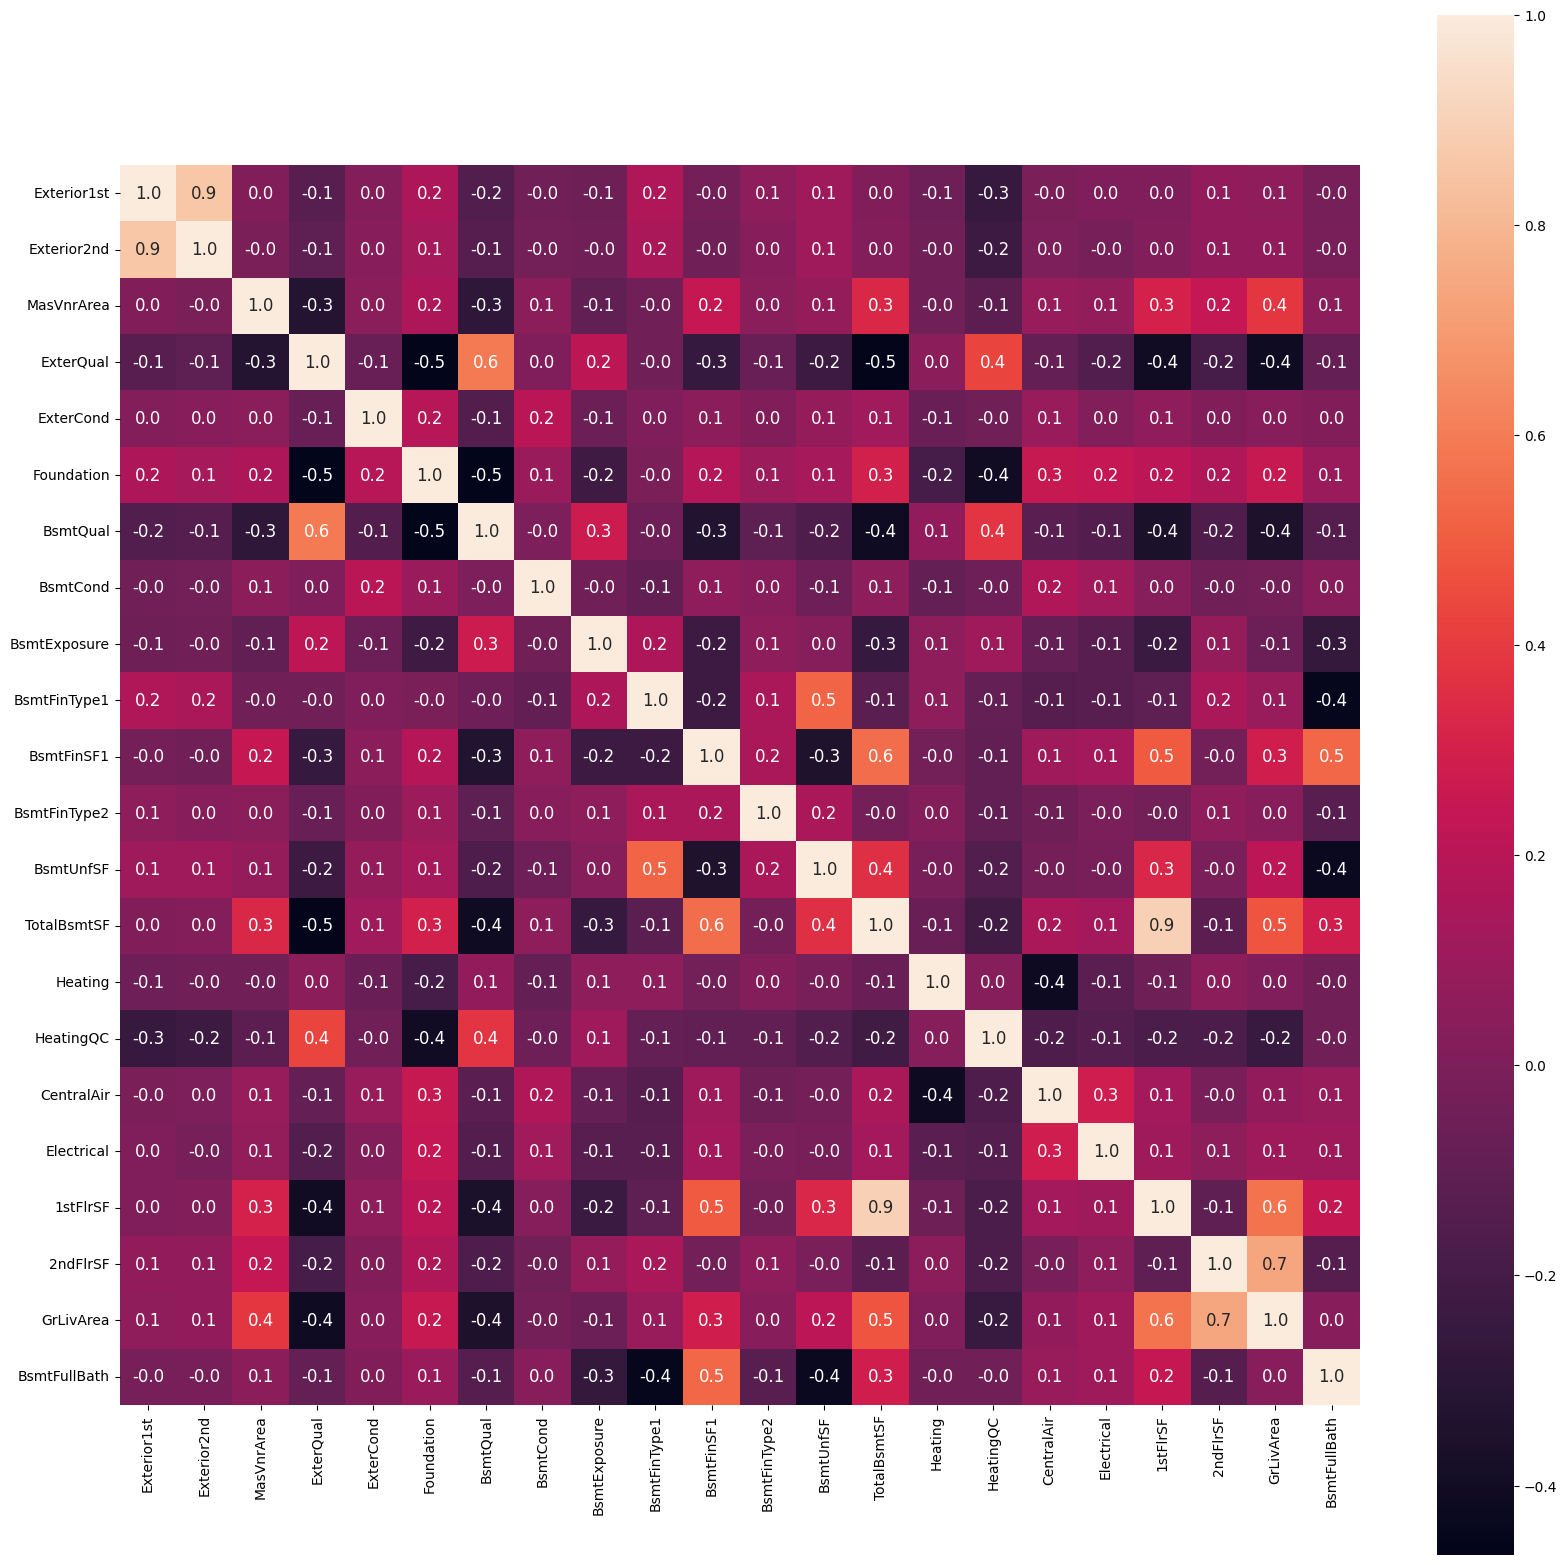

In [ ]:
correlation = G2.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True,
annot_kws={'size':12})

In [ ]:
G2 = G2.drop([ 'BsmtCond', 'Exterior2nd'] , axis
= 1)

In [ ]:
G2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Exterior1st   1420 non-null   int64  
 1   MasVnrArea    1420 non-null   float64
 2   ExterQual     1420 non-null   int64  
 3   ExterCond     1420 non-null   int64  
 4   Foundation    1420 non-null   int64  
 5   BsmtQual      1420 non-null   int64  
 6   BsmtExposure  1420 non-null   int64  
 7   BsmtFinType1  1420 non-null   int64  
 8   BsmtFinSF1    1420 non-null   float64
 9   BsmtFinType2  1420 non-null   int64  
 10  BsmtUnfSF     1420 non-null   float64
 11  TotalBsmtSF   1420 non-null   int64  
 12  Heating       1420 non-null   int64  
 13  HeatingQC     1420 non-null   int64  
 14  CentralAir    1420 non-null   int64  
 15  Electrical    1420 non-null   int64  
 16  1stFlrSF      1420 non-null   int64  
 17  2ndFlrSF      1420 non-null   float64
 18  GrLivArea     1420 non-null   int

<Axes: >

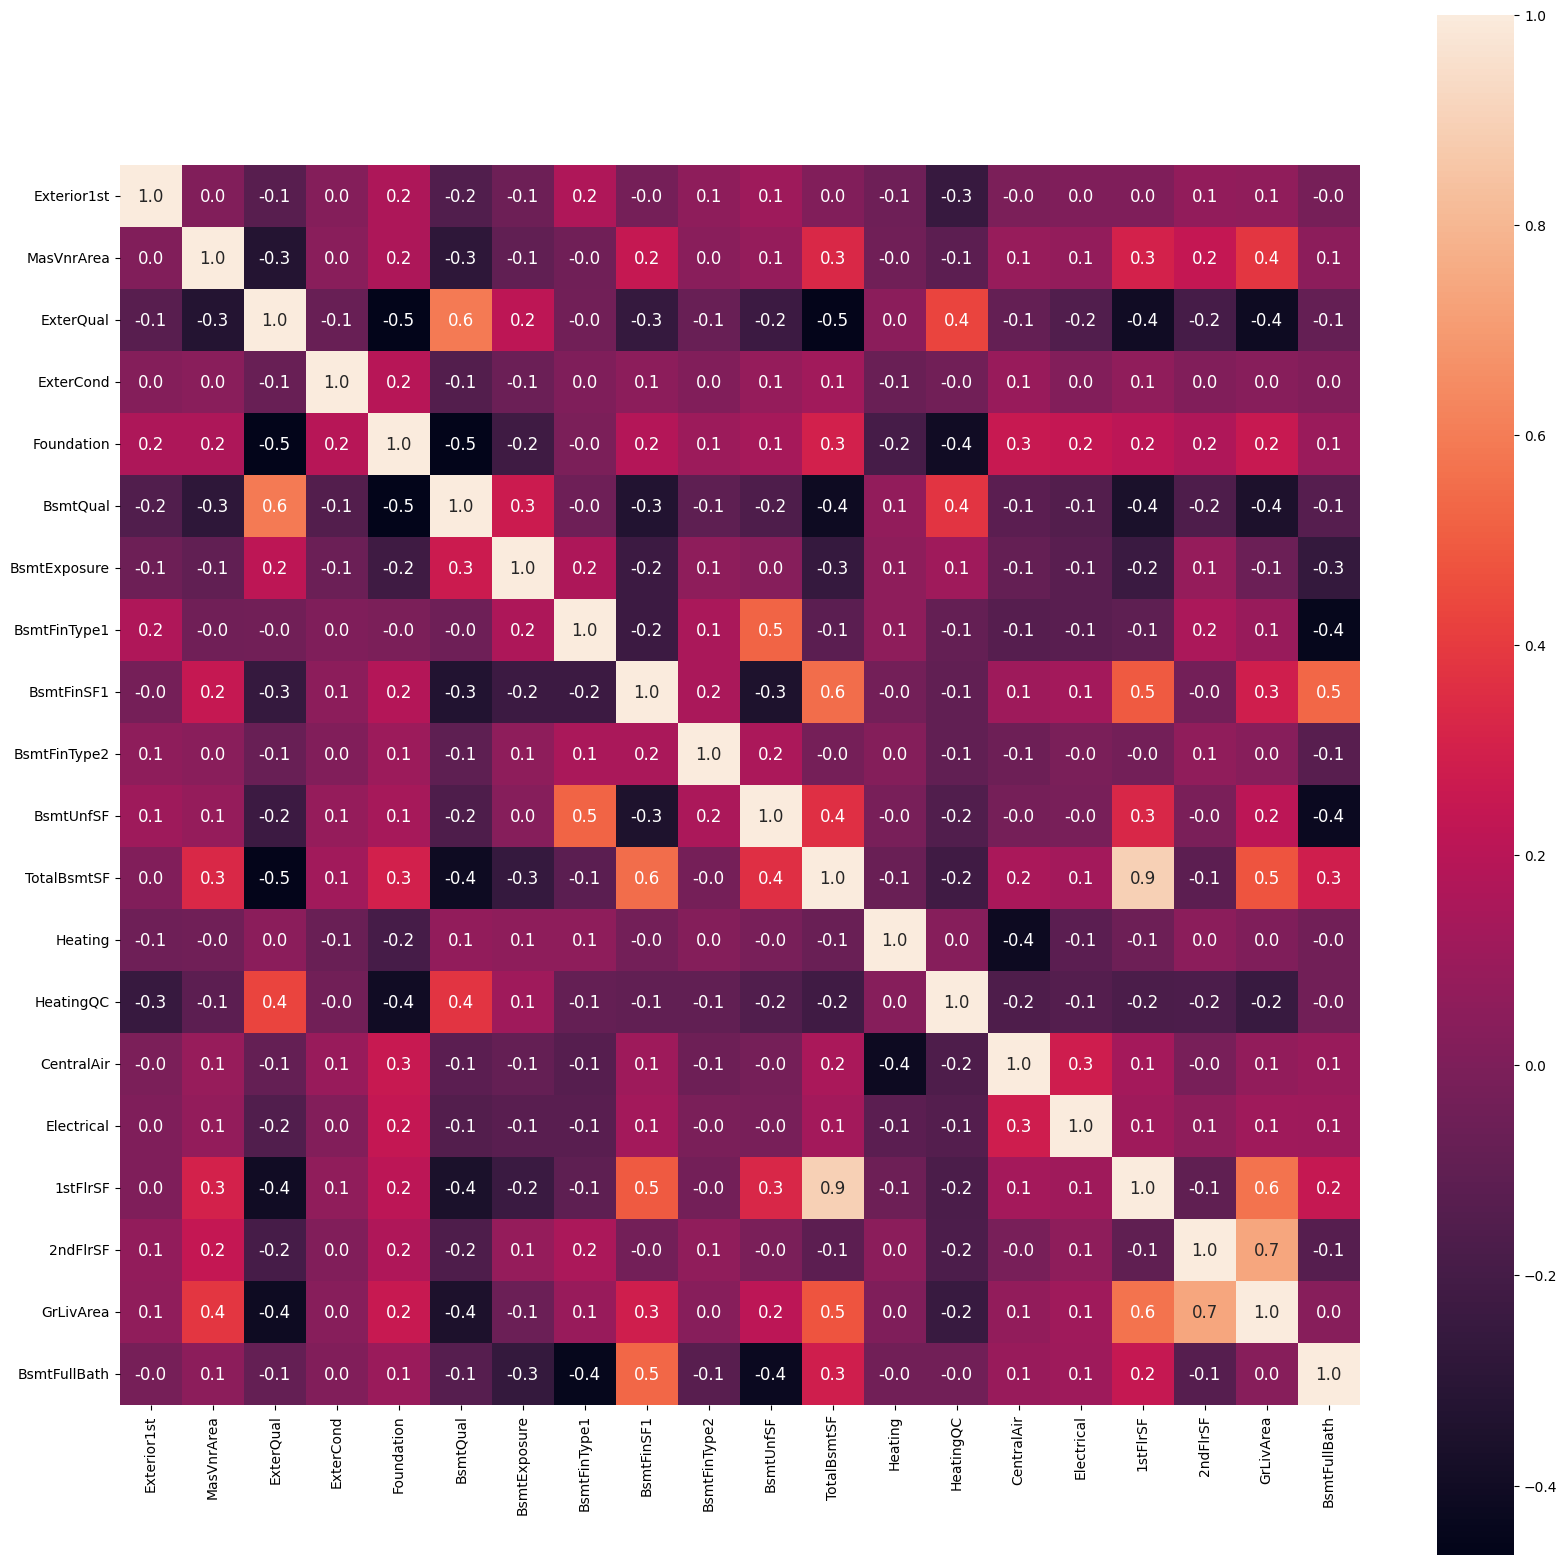

In [ ]:
correlation = G2.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True,
annot_kws={'size':12})

<Axes: >

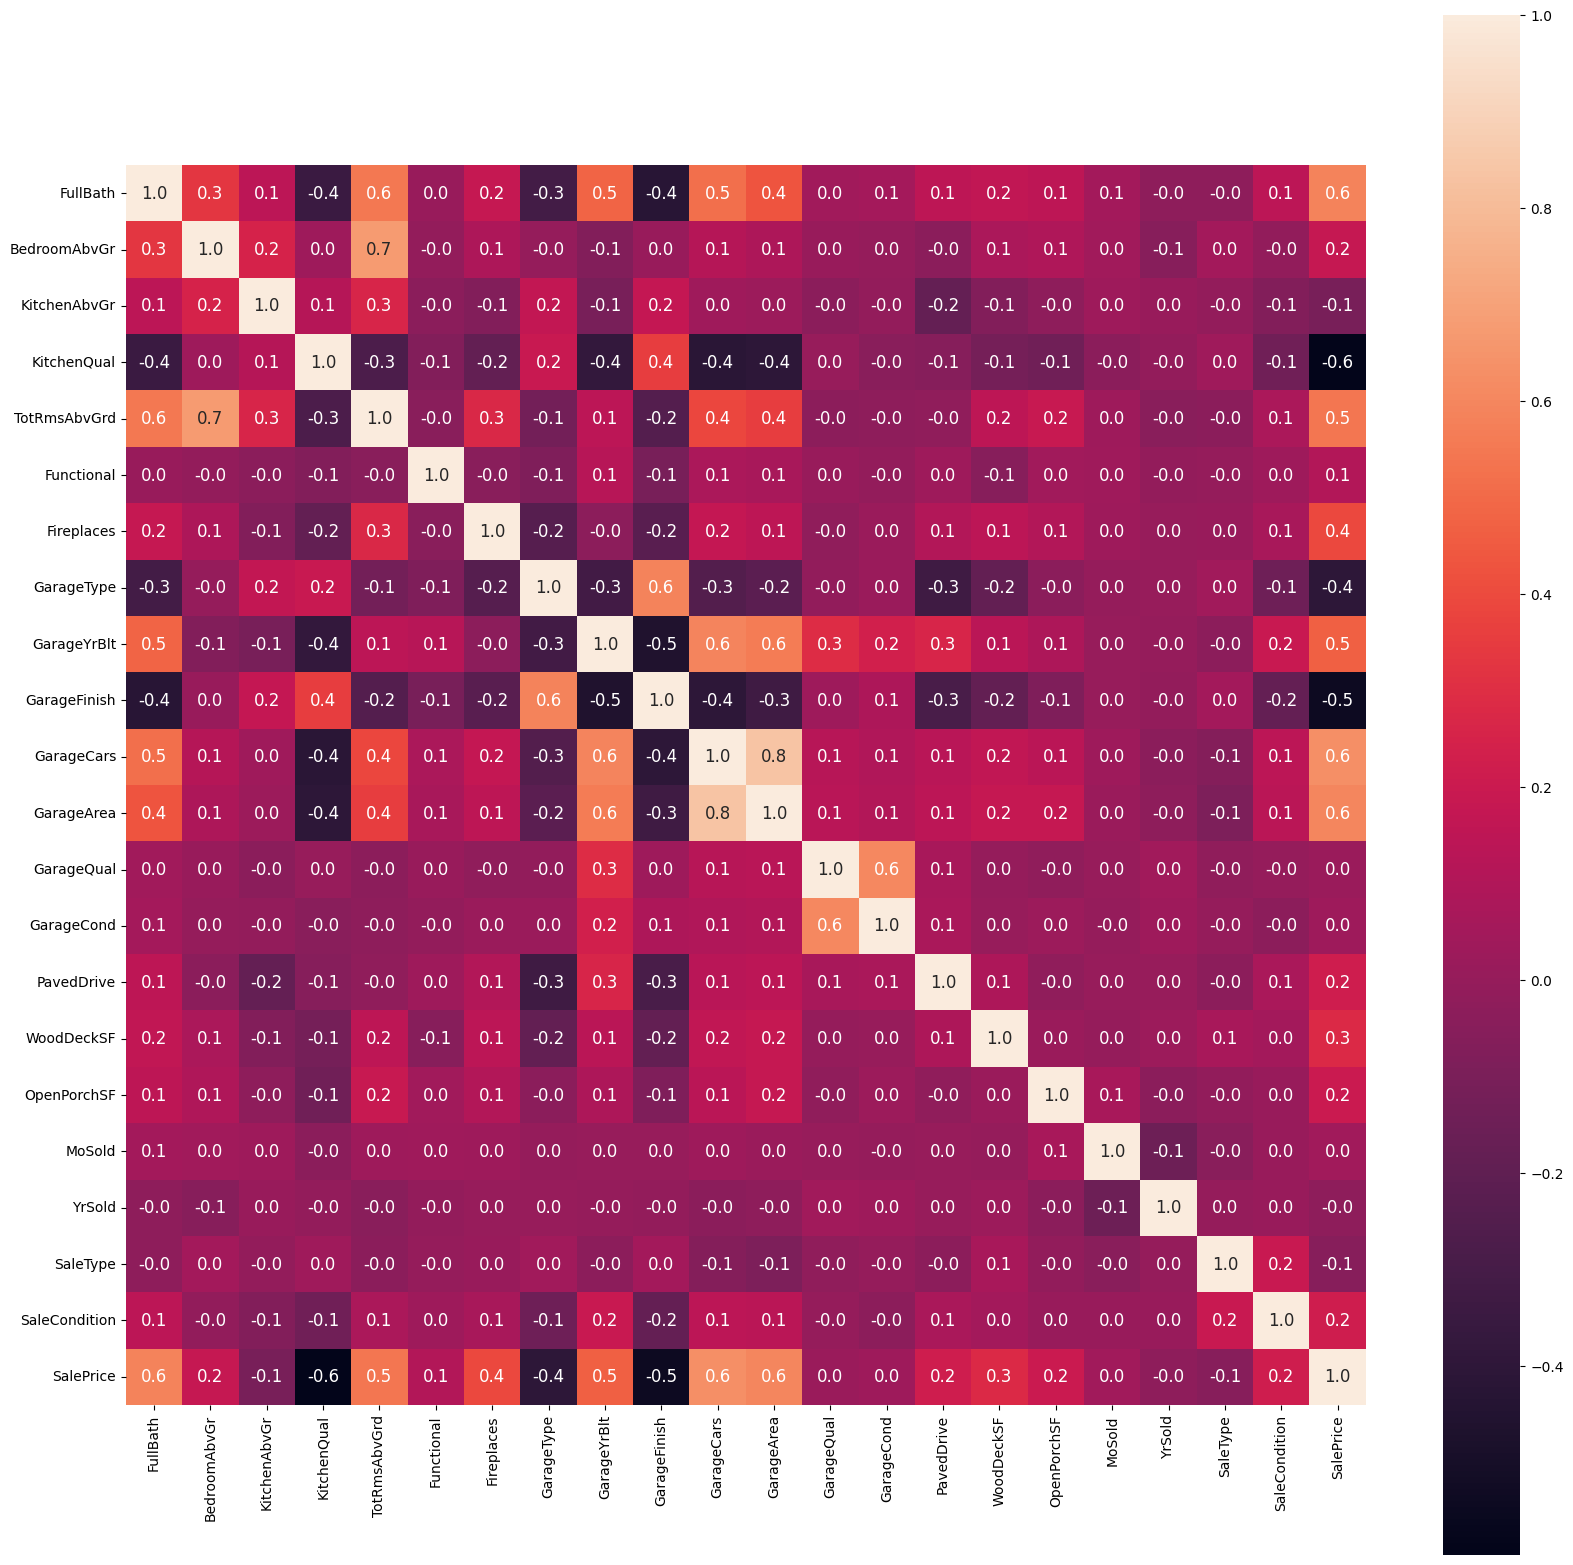

In [ ]:
correlation = G3.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True,
annot_kws={'size':12})

In [ ]:
G3 = G3.drop([ 'SaleType', 'YrSold','MoSold' ,'GarageCond','GarageQual','Functional'] , axis
= 1)

In [ ]:
G3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   FullBath       1420 non-null   float64
 1   BedroomAbvGr   1420 non-null   float64
 2   KitchenAbvGr   1420 non-null   float64
 3   KitchenQual    1420 non-null   int64  
 4   TotRmsAbvGrd   1420 non-null   int64  
 5   Fireplaces     1420 non-null   float64
 6   GarageType     1420 non-null   int64  
 7   GarageYrBlt    1420 non-null   float64
 8   GarageFinish   1420 non-null   int64  
 9   GarageCars     1420 non-null   float64
 10  GarageArea     1420 non-null   float64
 11  PavedDrive     1420 non-null   int64  
 12  WoodDeckSF     1420 non-null   float64
 13  OpenPorchSF    1420 non-null   float64
 14  SaleCondition  1420 non-null   int64  
 15  SalePrice      1420 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 188.6 KB


<Axes: >

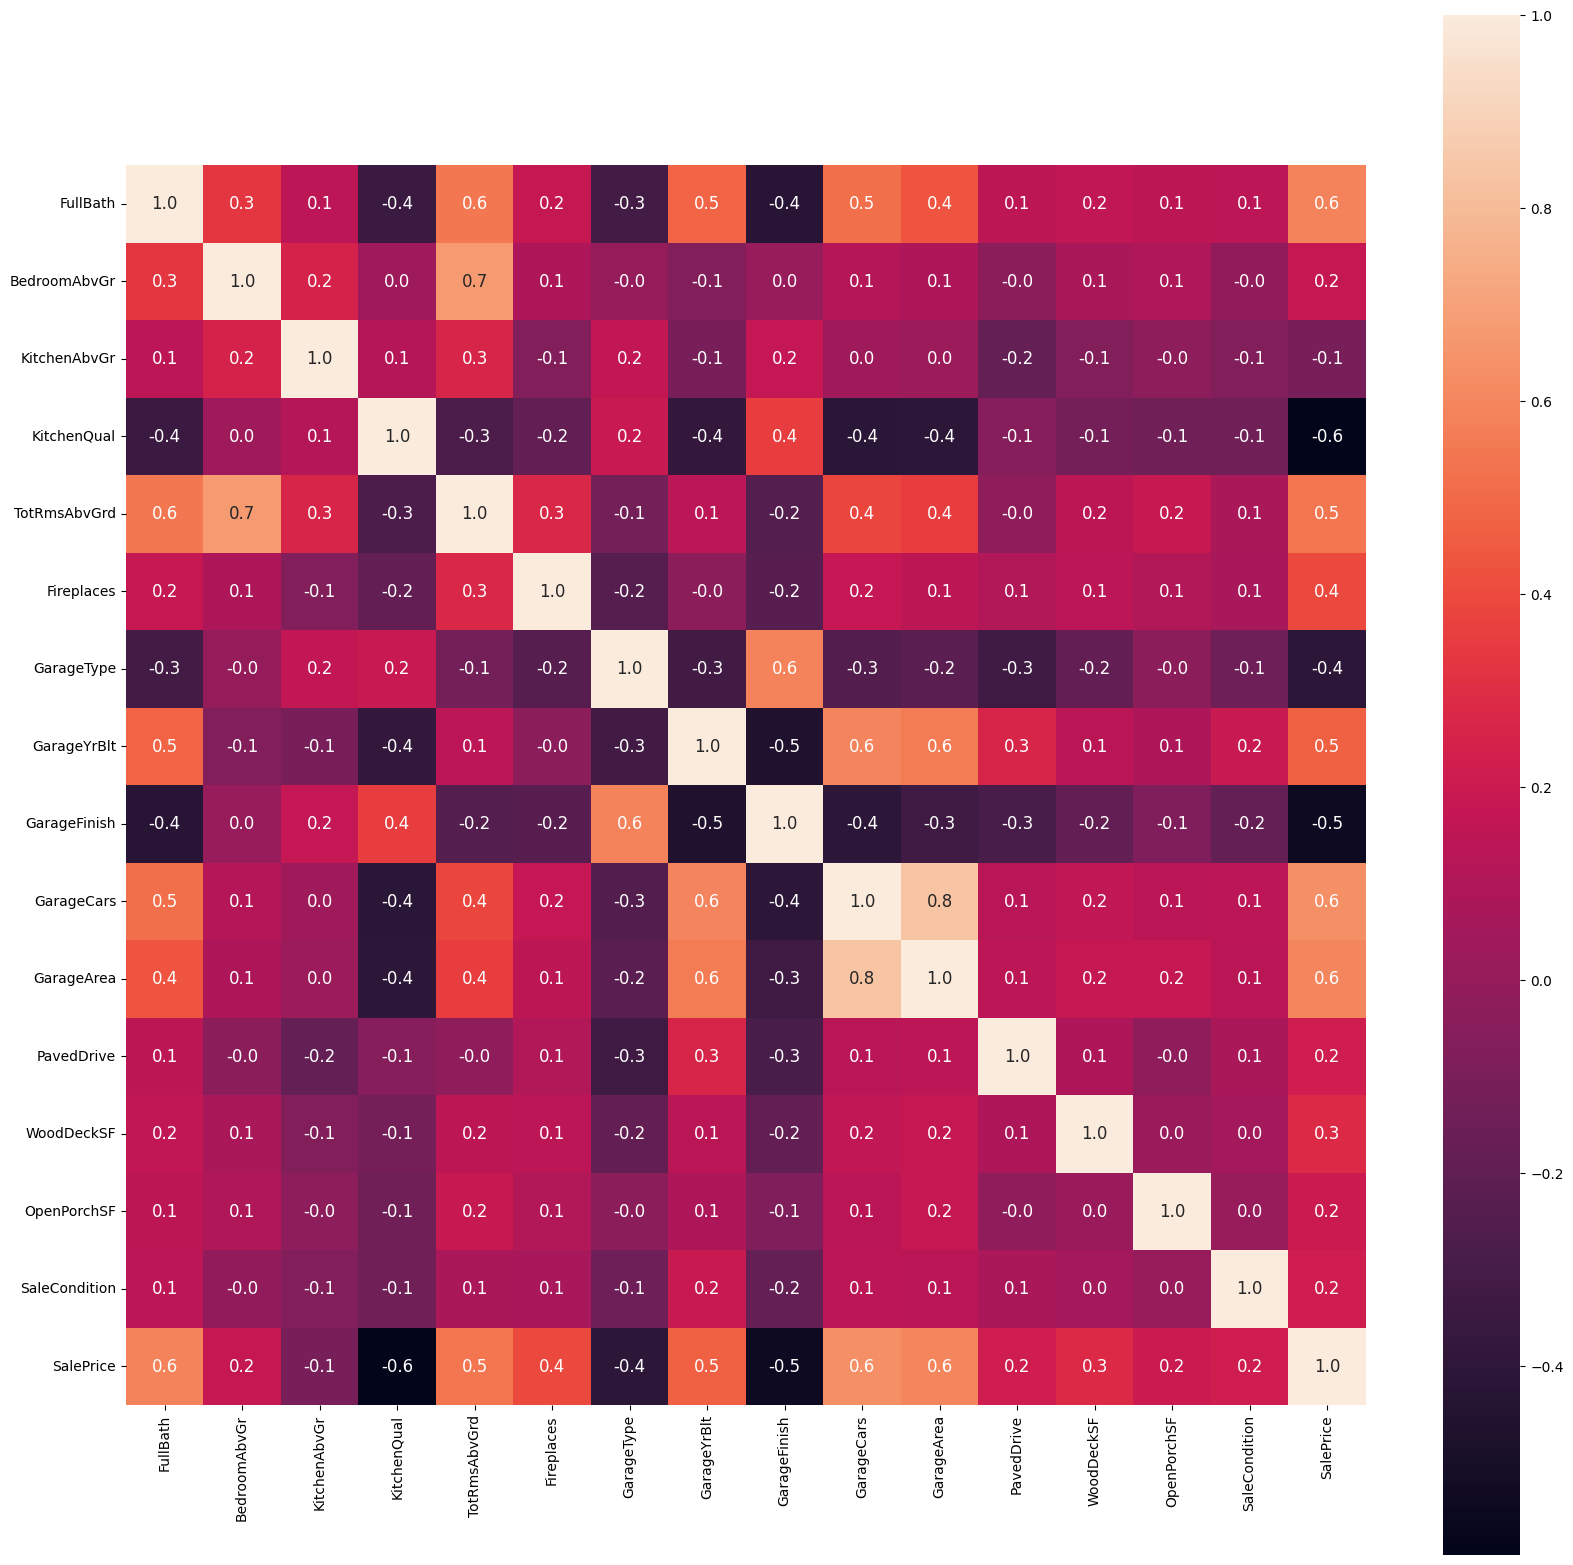

In [ ]:
correlation = G3.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True,
annot_kws={'size':12})

In [ ]:
G1.info()
G2.info()
G3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    1420 non-null   int64  
 1   LotFrontage   1420 non-null   float64
 2   LotArea       1420 non-null   int64  
 3   LotShape      1420 non-null   int64  
 4   LandSlope     1420 non-null   int64  
 5   BldgType      1420 non-null   int64  
 6   HouseStyle    1420 non-null   int64  
 7   OverallQual   1420 non-null   int64  
 8   YearBuilt     1420 non-null   int64  
 9   YearRemodAdd  1420 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 122.0 KB
<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 0 to 1459
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Exterior1st   1420 non-null   int64  
 1   MasVnrArea    1420 non-null   float64
 2   ExterQual     1420 non-null   int64  
 3   ExterCon